# TS5: Estimación espectral: Ancho de banda de señales reales

### Gonzalo Constenla

[Nbviewer](https://nbviewer.org/github/GConstenlaP/AyPS/blob/main/TS5/TS5.ipynb)
[GitHub](https://github.com/GConstenlaP/AyPS/blob/main/TS5/TS5.ipynb)

## Introducción
El objetivo del presente trabajo es leer y analizar distintas señales de distintos tipos y determinar por medio de un metodo de estimación espectral a elección personal (entre los vistos en el curso), la respectiva Densidad espectral de potencia de la señal y el ancho de banda.

#### Marco Teórico
La *Herramienta que mide la densidad espectral de potencia* es el Periodograma (PSD), el cual esta definido como la DTFT de la secuencia de autocorrelación de la señal: r_x (k).
formula 1:
formula 2:

El problema es que en una señal Real, no conocemos la secuencia real de autocorrelación, para ello deberíamos conocer las infinitas muestras desde n= -inf hasta mas inf. lo cual resulta físicamente imposible.
A raiz de esto, surgieron 2 enfoques: Por un lado trabajar en el dominio temporal, definiendo un estimador para la autocorrelación de la señal rˆ_x (k), aplicar una ventana y luego calcular la Transofrmada de Fourier y terminar de obtener la PSD. (Esto es blackman tukey)

Por otro lado, se puede trabajar en el dominio de la frecuencia, obtenieniendo las muestras x (n), aplicando la transformada y luego calcular la potencia al cuadrado para obtener la PSD.

El problema de este método es que 

## Desarrollo



Importo librerias y defino función que toma como parametros la señal, la frecuencia de muestreo, la ventana que quiera aplicar, el tamaño del bloque en muestras(L) y el porcentaje que quiera determinar como limite para definir el ancho de banda de la señal.
En este trabajo se utilizo la ventana Hann y el ancho de banda encerrando 98% de la potencia de las frecuencias de la señal.
Además se trabajaron con distintos tamaños de bloque, probando distinto numero de muestras por bloque, para observar su influencia en los resultados. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

from scipy import signal as sig
import scipy.io as sio
from scipy.io.wavfile import write

import sounddevice as sd


import os

#en que carpeta estoy
#print(os.getcwd())

#agrego mi carpeta al directorio
os.chdir(r'C:\Users\Gonza\AyPS\Repositorio AyPS Git\TS5')

#importo lib de señales
import scipy.signal.windows as win

from scipy import signal

def calcular_psd_y_bw(x, fs, ventana, nperseg, porcentaje):

    f, Pxx = signal.welch(
        x,
        fs=fs,
        window=ventana,
        nperseg=nperseg,
        noverlap=nperseg // 2,
        nfft=None,
        detrend='constant',
        return_onesided=True,
        scaling='density',
        axis=-1,
        average='mean'
    )
    

    df = f[1] - f[0]

    potencia_acum = np.cumsum(Pxx) * df
    potencia_total = potencia_acum[-1]

    bw = f[np.where(potencia_acum >= porcentaje * potencia_total)[0][0]]

    return f, Pxx, bw

### Señal 1: Electrocardiograma


Ancho de banda de 98% potencia de ECG con bloques de 1000 muestras : 27.000 Hz


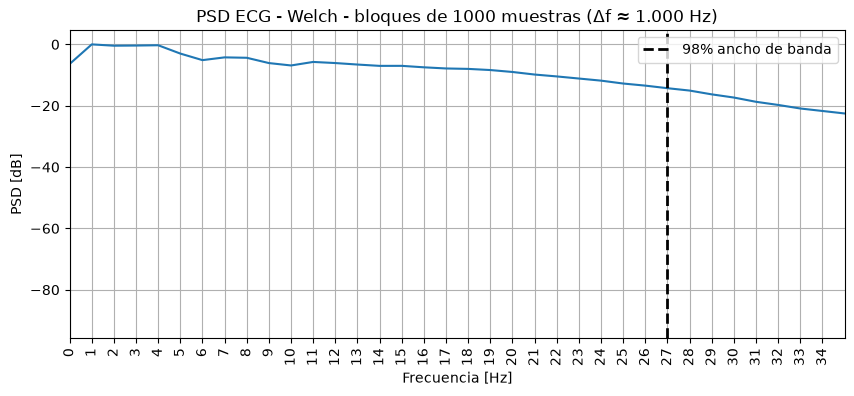

Ancho de banda de 98% potencia de ECG con bloques de 2000 muestras : 27.000 Hz


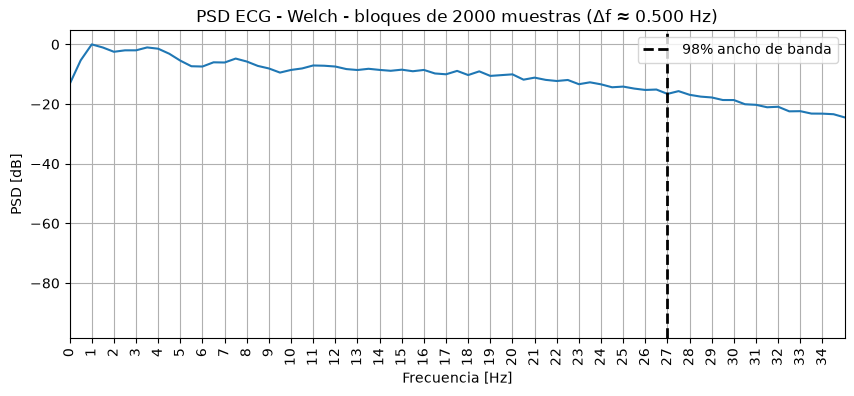

Ancho de banda de 98% potencia de ECG con bloques de 8000 muestras : 27.875 Hz


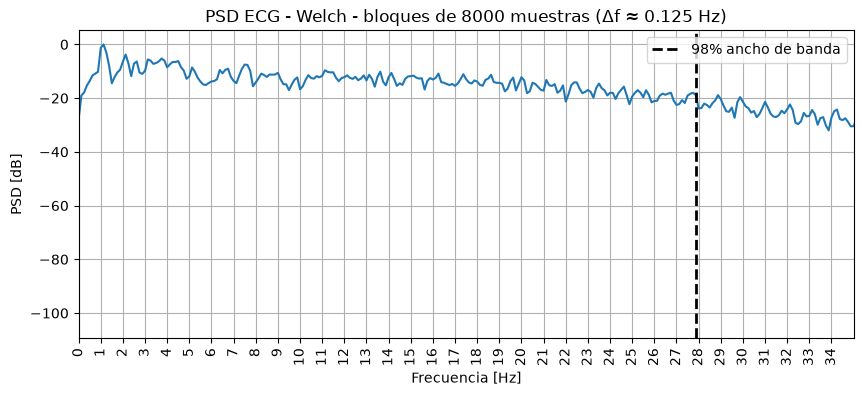

In [2]:
#%% ################### Lectura de ECG sin ruido ###################

fs_ecg = 1000 # Hz

ecg_one_lead = np.load('ecg_sin_ruido.npy')

#los tiempos: son el vector de las muestras divido la frecuencia
t_ecg = np.arange(len(ecg_one_lead)) / fs_ecg

#print(len(ecg_one_lead)) #tengo 30mil muestras
#la resolucion frecuencial, deltaf es = fs/nperseg, ya que nperseg son las muestras de cada bloque
# con nperseg mas chico tengo mas bloques, entonces tengo menos varianza pero menor resulcion espectral.


# Grafico para bloques de 1000, 2000, etc muestras
nperseg_values = [1000,2000,8000]

for nperseg in nperseg_values:
# UTLIZIZO VENTANA HANN

# UTLIZIZO VENTANA HANN 
    f_ecg, Pxx_ecg, bw_ecg = calcular_psd_y_bw(ecg_one_lead, fs_ecg, ventana = 'hann', nperseg = nperseg, porcentaje = 0.98)
    print(f'Ancho de banda de 98% potencia de ECG con bloques de {nperseg} muestras : {bw_ecg:.3f} Hz')
    Pxx_norm = Pxx_ecg / np.max(Pxx_ecg) # PSD en dB
    Pxx_db = 10 * np.log10(Pxx_norm)
    plt.figure(figsize=(10, 4))
    plt.plot(f_ecg, Pxx_db)
    plt.xlim(0, 35)
    plt.xticks(np.arange(0, 35, 1), rotation=90)
    plt.xlabel('Frecuencia [Hz]')
    plt.axvline(bw_ecg, color='black', linestyle='dashed', linewidth=2, label='98% ancho de banda')
    plt.ylabel('PSD [dB]')
    plt.title(f'PSD ECG - Welch - bloques de {nperseg} muestras (Δf ≈ {fs_ecg/nperseg:.3f} Hz)')
    plt.grid()
    plt.legend(loc='upper right')
    plt.show()



### Señal 2: pletismografía


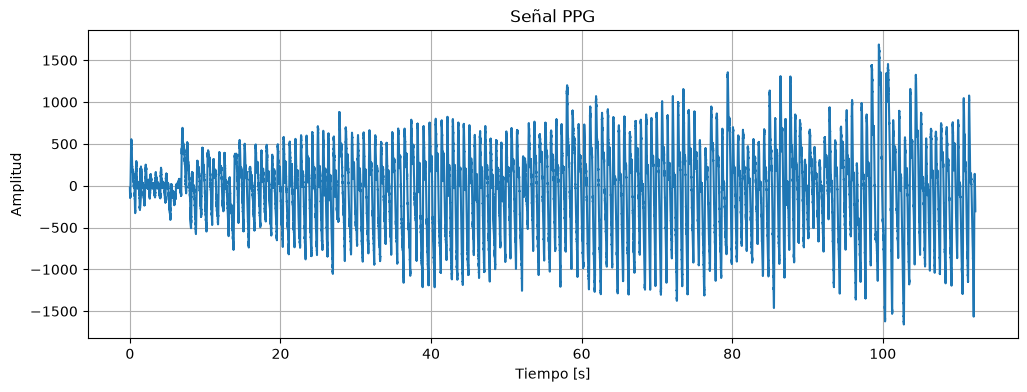

Ancho de banda de 98% potencia de ECG con bloques de 400 muestras : 5.000 Hz


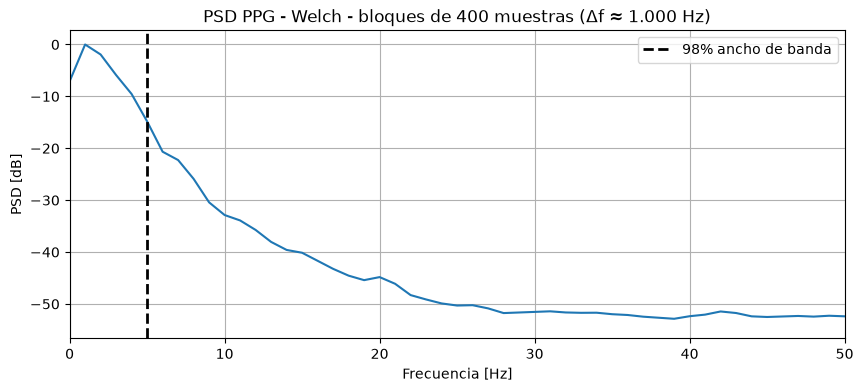

Ancho de banda de 98% potencia de ECG con bloques de 800 muestras : 4.500 Hz


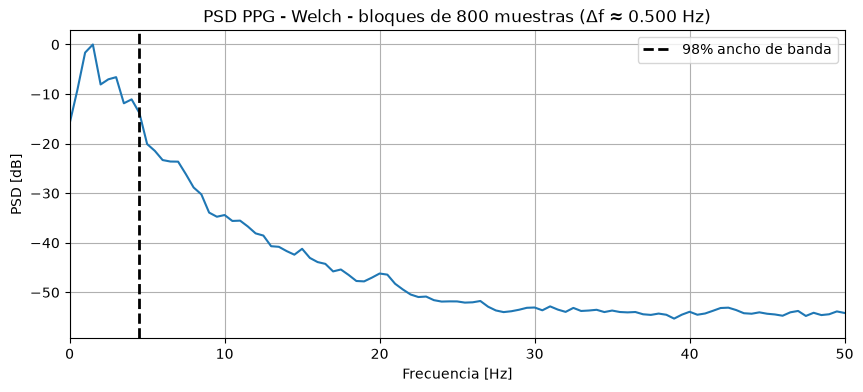

Ancho de banda de 98% potencia de ECG con bloques de 3200 muestras : 4.375 Hz


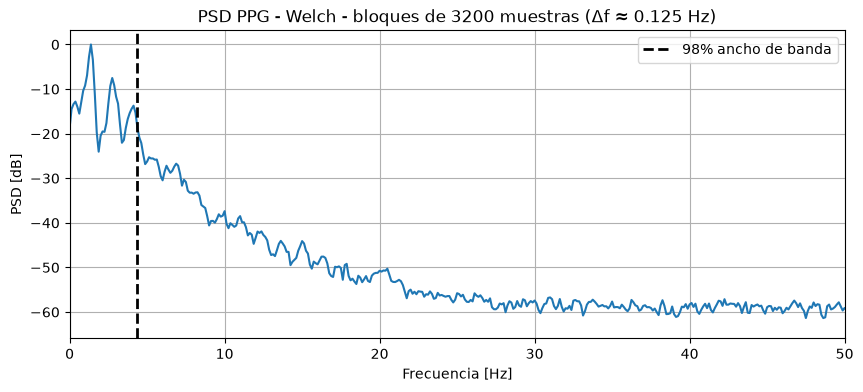

In [3]:
#%% ##################################### Lectura de pletismografía (PPG)  #####################################

fs_ppg = 400 # Hz

##################
## PPG sin ruido
##################

ppg = np.load('ppg_sin_ruido.npy')

N_ppg = len(ppg)
t_ppg = np.arange(N_ppg) / fs_ppg
# print(f'Cantidad de muestras: {N_ppg}') # 44919 muestras y 112.3 s de duracion

plt.figure(figsize=(12, 4))
plt.plot(t_ppg, ppg)

plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Señal PPG')
plt.grid()
plt.show()


# Como tengo n = 44919 y fs = 400hz

nperseg_values_ppg = [400, 800, 3200]
    
for nperseg1 in nperseg_values_ppg:
# UTLIZIZO VENTANA HANN
    f_ppg, Pxx_ppg, bw_ppg = calcular_psd_y_bw(ppg, fs_ppg, ventana = 'hann', nperseg =  nperseg1, porcentaje = 0.98)
    print(f'Ancho de banda de 98% potencia de PPG con bloques de {nperseg1} muestras : {bw_ppg:.3f} Hz')

    Pxx_ppg_norm = Pxx_ppg / np.max(Pxx_ppg)
    # PSD en dB
    Pxx_ppg_db = 10 * np.log10(Pxx_ppg_norm)


    plt.figure(figsize=(10, 4))
    plt.plot(f_ppg, Pxx_ppg_db)
    # plt.xlim(0, 35)
    # plt.xticks(np.arange(0, 35, 1), rotation=90)
    plt.xlabel('Frecuencia [Hz]')
    plt.xlim(0,50)
    plt.axvline(bw_ppg, color='black', linestyle='dashed', linewidth=2, label='98% ancho de banda')
    plt.ylabel('PSD [dB]')
    plt.title(f'PSD PPG - Welch - bloques de {nperseg1} muestras (Δf ≈ {fs_ppg/nperseg1:.3f} Hz)')
    plt.grid()
    plt.legend(loc='upper right')
    plt.show()

### Señal 3: Distintas Señales de Audio
#### Audio 1: "La cucaracha"

Cantidad de muestras: 144000


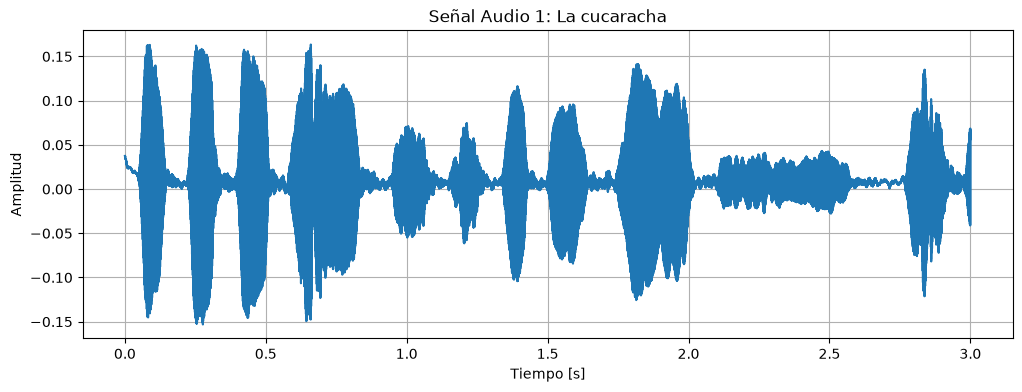

Ancho de banda de 98% potencia con bloques de 1000 muestras : 1968.000 Hz


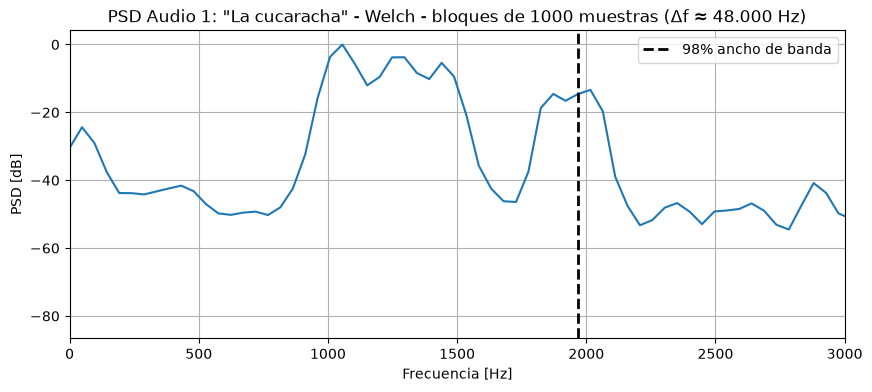

Ancho de banda de 98% potencia con bloques de 24000 muestras : 2006.000 Hz


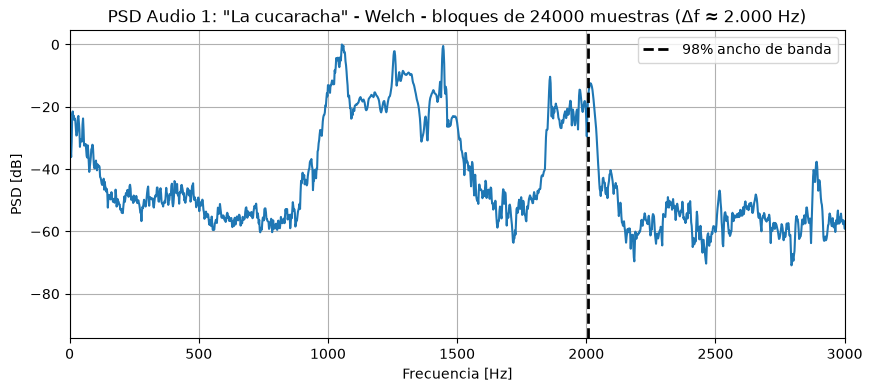

Ancho de banda de 98% potencia con bloques de 48000 muestras : 2011.000 Hz


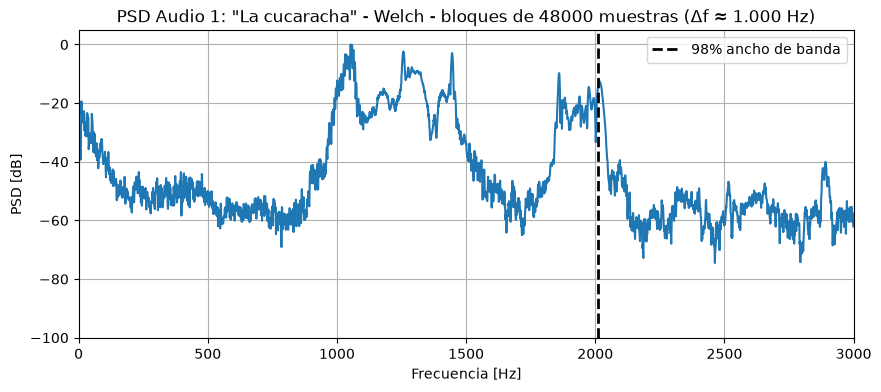

In [6]:
# %% ##################################### Lectura audios#####################################

fs_audio, audio1 = sio.wavfile.read('la cucaracha.wav')
fs_audio, audio2  = sio.wavfile.read('prueba psd.wav')
fs_audio, audio3 = sio.wavfile.read('silbido.wav')

#fs es 48khz
N_audio1 = len(audio1)
t_audio1 = np.arange(N_audio1) / fs_audio

print(f'Cantidad de muestras: {N_audio1}') # 144000


plt.figure(figsize=(12, 4))
plt.plot(t_audio1, audio1)

plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Señal Audio 1: La cucaracha')
plt.grid()
plt.show()


nperseg_values_audio1 = [1000, 24000, 48000]
    
for nperseg_audio1 in nperseg_values_audio1:
# UTLIZIZO VENTANA HANN
    f_audio1, Pxx_audio1, bw_audio1 = calcular_psd_y_bw(audio1, fs_audio, ventana = 'hann', nperseg =  nperseg_audio1 , porcentaje = 0.98)
    print(f'Ancho de banda de 98% potencia con bloques de {nperseg_audio1} muestras : {bw_audio1:.3f} Hz')

    Pxx__audio1_norm = Pxx_audio1 / np.max(Pxx_audio1)
    # PSD en dB
    Pxx_audio1_db = 10 * np.log10(Pxx__audio1_norm)


    plt.figure(figsize=(10, 4))
    plt.plot(f_audio1, Pxx_audio1_db)
    plt.xlim(0, 3000)
    # plt.xticks(np.arange(0, 35, 1), rotation=90)
    plt.xlabel('Frecuencia [Hz]')
    plt.axvline(bw_audio1, color='black', linestyle='dashed', linewidth=2, label='98% ancho de banda')
    plt.ylabel('PSD [dB]')
    plt.title(f'PSD Audio 1: "La cucaracha" - Welch - bloques de {nperseg_audio1} muestras (Δf ≈ {fs_audio/nperseg_audio1:.3f} Hz)')
    plt.grid()
    plt.legend(loc='upper right')
    plt.show()



#### Audio 2: "Prueba PSD"

Audio 2 - Cantidad de muestras: 144000
Audio 2 - Duración: 3.00 s


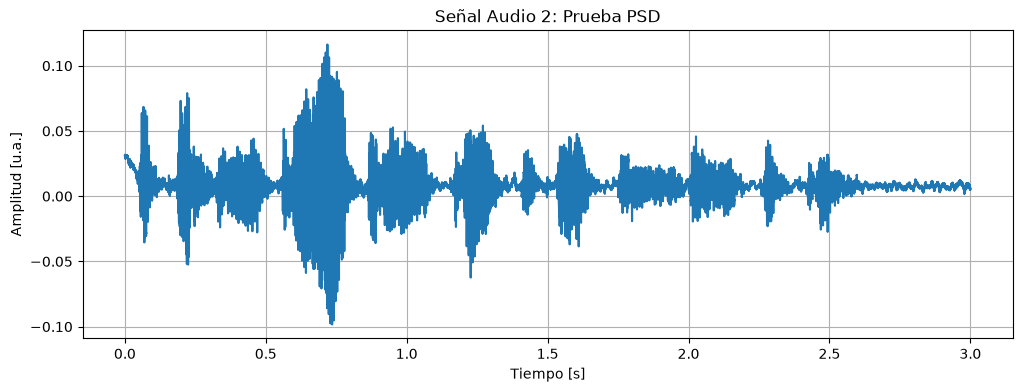

Audio 2 - nperseg=1000: Δf ≈ 48.000 Hz, BW98 = 1632.000 Hz


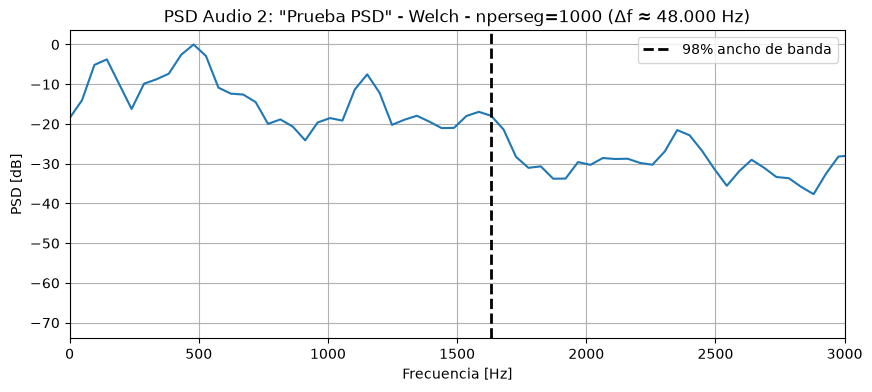

Audio 2 - nperseg=24000: Δf ≈ 2.000 Hz, BW98 = 1636.000 Hz


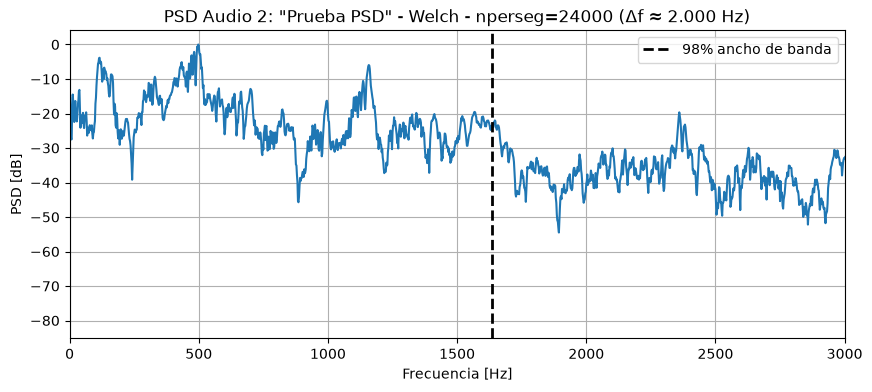

Audio 2 - nperseg=48000: Δf ≈ 1.000 Hz, BW98 = 1605.000 Hz


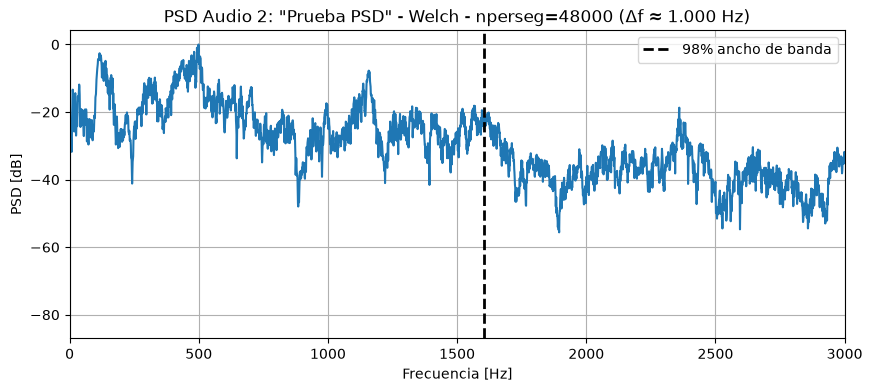

In [7]:
# %% ##################################### AUDIO 2 #####################################

N_audio2 = len(audio2)
t_audio2 = np.arange(N_audio2) / fs_audio

print(f'Audio 2 - Cantidad de muestras: {N_audio2}')
print(f'Audio 2 - Duración: {N_audio2/fs_audio:.2f} s')


# Señal temporal
plt.figure(figsize=(12, 4))
plt.plot(t_audio2, audio2)

plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [u.a.]')
plt.title('Señal Audio 2: Prueba PSD')
plt.grid()
plt.show()


nperseg_values_audio2 = [1000, 24000, 48000]

for nperseg_audio2 in nperseg_values_audio2:

    f_audio2, Pxx_audio2, bw_audio2 = calcular_psd_y_bw(
        audio2,
        fs_audio,
        ventana='hann',
        nperseg=nperseg_audio2,
        porcentaje=0.98
    )

    print(
        f'Audio 2 - nperseg={nperseg_audio2}: '
        f'Δf ≈ {fs_audio/nperseg_audio2:.3f} Hz, '
        f'BW98 = {bw_audio2:.3f} Hz'
    )

    Pxx_audio2_norm = Pxx_audio2 / np.max(Pxx_audio2)

    # PSD en dB
    Pxx_audio2_db = 10 * np.log10(Pxx_audio2_norm)

    plt.figure(figsize=(10, 4))
    plt.plot(f_audio2, Pxx_audio2_db)

    plt.xlim(0, 3000)

    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('PSD [dB]')

    plt.axvline(
        bw_audio2,
        color='black',
        linestyle='dashed',
        linewidth=2,
        label='98% ancho de banda'
    )

    plt.title(
        f'PSD Audio 2: "Prueba PSD" - Welch - '
        f'nperseg={nperseg_audio2} '
        f'(Δf ≈ {fs_audio/nperseg_audio2:.3f} Hz)'
    )

    plt.grid()
    plt.legend(loc='upper right')
    plt.show()
    

#### Audio 2: "Silbido"

In [ ]:
# %% audio 3

N_audio3 = len(audio3)
t_audio3 = np.arange(N_audio3) / fs_audio

plt.figure(figsize=(12, 4))
plt.plot(t_audio3, audio3)

plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Señal Audio 1: La cucaracha')
plt.grid()
plt.show()




# PSD mediante Welch
nperseg_values_audio3 = [1000, 24000, 48000]

for nperseg_audio3 in nperseg_values_audio3:

    f_audio3, Pxx_audio3, bw_audio3 = calcular_psd_y_bw(audio3, fs_audio, ventana='hann', nperseg=nperseg_audio3, porcentaje=0.98)

    print(
        f'Audio 3 - nperseg={nperseg_audio3}: '
        f'Δf ≈ {fs_audio/nperseg_audio3:.3f} Hz, '
        f'BW98 = {bw_audio3:.3f} Hz'
    )

    Pxx_audio3_norm = Pxx_audio3 / np.max(Pxx_audio3)

    # PSD en dB
    Pxx_audio3_db = 10 * np.log10(Pxx_audio3_norm)

    plt.figure(figsize=(10, 4))
    plt.plot(f_audio3, Pxx_audio3_db)

    # plt.xlim(0, 3000)

    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('PSD [dB]')
    plt.xlim(0,8000)
    plt.axvline(
        bw_audio3,
        color='black',
        linestyle='dashed',
        linewidth=2,
        label='98% ancho de banda'
    )

    plt.title(
        f'PSD Audio 3: "Silbido" - Welch - '
        f'nperseg={nperseg_audio3} '
        f'(Δf ≈ {fs_audio/nperseg_audio3:.3f} Hz)'
    )

    plt.grid()
    plt.legend(loc='upper right')
    plt.show()